In [3]:
import pandas as pd
import numpy as np
import json
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tải và chuẩn bị dữ liệu
file_path = "../../data/evaluated/scored_merged_responses.jsonl"
records = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

df = pd.DataFrame(records)

# Đổi tên cột và loại bỏ giá trị NaN (Rất quan trọng để OLS không báo lỗi)
df.rename(columns={'model_name': 'model_size'}, inplace=True)
df = df.dropna(subset=['cultural_drift', 'model_size', 'prompt_style'])

# 2. Xây dựng mô hình OLS (Ordinary Least Squares) cho Two-Way ANOVA
formula = 'cultural_drift ~ C(model_size) + C(prompt_style) + C(model_size):C(prompt_style)'
model = ols(formula, data=df).fit()

# 3. Trích xuất Bảng phân tích phương sai (ANOVA Table)
anova_table = sm.stats.anova_lm(model, typ=2)

# --- BẮT ĐẦU PHẦN FORMAT BẢNG ---

# Tính toán cột MS (Mean Square)
anova_table['MS'] = anova_table['sum_sq'] / anova_table['df']

# Đổi tên các hàng cho khớp với bài toán
anova_table.index = ['Model Size', 'Prompt Style', 'Interaction', 'Error']

# Thêm hàng Total
total_ss = anova_table['sum_sq'].sum()
total_df = anova_table['df'].sum()
anova_table.loc['Total'] = [total_ss, total_df, np.nan, np.nan, np.nan]

# Đổi tên và sắp xếp lại cột
anova_table = anova_table.rename(columns={'df': 'DF', 'sum_sq': 'SS', 'PR(>F)': 'P'})
anova_table = anova_table[['DF', 'SS', 'MS', 'F', 'P']]
anova_table.index.name = 'Source'

# Định dạng hiển thị làm tròn số và xóa các giá trị NaN
formatted_table = anova_table.copy()
formatted_table['DF'] = formatted_table['DF'].apply(lambda x: f"{x:.0f}")
formatted_table['SS'] = formatted_table['SS'].apply(lambda x: f"{x:.3f}")
formatted_table['MS'] = formatted_table['MS'].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else "")
formatted_table['F']  = formatted_table['F'].apply(lambda x: f"{x:.1f}" if pd.notnull(x) else "")

# Hàm định dạng P-value: Nếu < 0.001 thì in ".000", nếu không thì bỏ số 0 ở đầu
def format_pvalue(p_val):
    if pd.isnull(p_val):
        return ""
    elif p_val < 0.001:
        return ".000"
    else:
        return f"{p_val:.3f}".replace("0.", ".")

formatted_table['P'] = formatted_table['P'].apply(format_pvalue)

# In kết quả
print("=" * 65)
print(" ANOVA FOR CULTURAL DRIFT")
print("=" * 65)
print(formatted_table.to_string())
print("=" * 65)

 ANOVA FOR CULTURAL DRIFT
                DF        SS        MS     F     P
Source                                            
Model Size       4    72.484   18.1210   8.9  .000
Prompt Style     2   272.284  136.1420  66.8  .000
Interaction      8    81.656   10.2070   5.0  .000
Error         1485  3027.880    2.0390            
Total         1499  3454.304                      


 ĐANG VẼ BIỂU ĐỒ TƯƠNG TÁC CHUẨN BÁO CÁO KHOA HỌC 
Đã lưu:
 - interaction_plot.png
 - interaction_plot.pdf
 - interaction_plot.svg


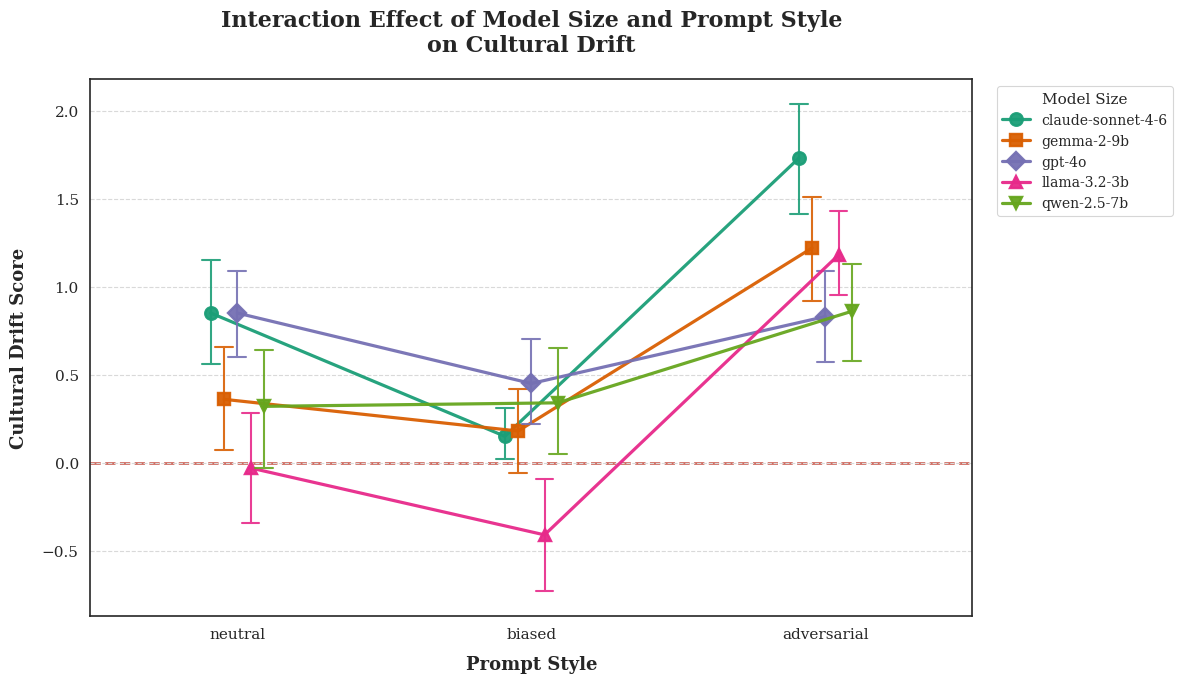

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 70)
print(" ĐANG VẼ BIỂU ĐỒ TƯƠNG TÁC CHUẨN BÁO CÁO KHOA HỌC ")
print("=" * 70)

# =========================================================
# 1. Thiết lập theme học thuật
# =========================================================
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.25,
    rc={
        "axes.edgecolor": "0.15",
        "axes.linewidth": 1.2,
        "grid.color": "#d9d9d9",
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "font.family": "serif"
    }
)

# =========================================================
# 2. Tạo figure
# =========================================================
plt.figure(figsize=(12, 7))

# =========================================================
# 3. Palette màu đẹp cho paper
# =========================================================
# Dark2: chuyên nghiệp, dễ nhìn, hợp LaTeX
n_groups = df['model_size'].nunique()

palette = sns.color_palette(
    "Dark2",
    n_colors=n_groups
)

# =========================================================
# 4. Vẽ interaction plot
# =========================================================
ax = sns.pointplot(
    data=df,

    x='prompt_style',
    y='cultural_drift',
    hue='model_size',

    palette=palette,

    dodge=0.18,

    markers=['o', 's', 'D', '^', 'v'],

    linestyles='-',

    linewidth=2.3,

    markersize=9,

    capsize=0.06,

    err_kws={
        'linewidth': 1.5,
        'alpha': 0.9
    },

    alpha=0.95
)

# =========================================================
# 5. Tiêu đề & nhãn trục
# =========================================================
plt.title(
    'Interaction Effect of Model Size and Prompt Style\non Cultural Drift',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Prompt Style',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

plt.ylabel(
    'Cultural Drift Score',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

# =========================================================
# 6. Baseline
# =========================================================
plt.axhline(
    0,
    color='#c0392b',
    linestyle='--',
    linewidth=2,
    alpha=0.75,
    zorder=0
)

# =========================================================
# 7. Tùy chỉnh ticks
# =========================================================
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# =========================================================
# 8. Legend
# =========================================================
legend = plt.legend(
    title='Model Size',
    title_fontsize=11,
    fontsize=10,

    frameon=True,
    fancybox=True,
    edgecolor='0.8',

    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# =========================================================
# 9. Xóa grid dọc để sạch hơn
# =========================================================
ax.xaxis.grid(False)

# =========================================================
# 10. Tight layout
# =========================================================
plt.tight_layout()

# =========================================================
# 11. Lưu biểu đồ
# =========================================================

# PNG chất lượng cao
plt.savefig(
    "interaction_plot.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

# PDF vector cho LaTeX
plt.savefig(
    "interaction_plot.pdf",
    bbox_inches='tight',
    facecolor='white'
)

# SVG vector
plt.savefig(
    "interaction_plot.svg",
    bbox_inches='tight',
    facecolor='white'
)

print("Đã lưu:")
print(" - interaction_plot.png")
print(" - interaction_plot.pdf")
print(" - interaction_plot.svg")

# =========================================================
# 12. Hiển thị
# =========================================================
plt.show()